In [24]:
from pathlib import Path
import random
from lxml import etree
import pandas as pd
import tiktoken
import re
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
from collections import Counter

from transformers import AutoTokenizer
from medical_rag.config import parse_pmc

## 创建Metadata dataframe

In [3]:
# 随机抽样

xml_files = list(
    Path(
        r"E:\字节跳动算法实习\data\PMC\extracted"
    ).rglob("*.xml")
)

print(len(xml_files))

sample_files = random.sample(
    xml_files,
    30000
)

3242816


In [4]:
# 创建dataframe来记录文献metadata

records = []

for file in sample_files:
    try:
        records.append(
            parse_pmc(file)
        )
    except:
        pass

df = pd.DataFrame(records)

print(df.head())

                                               title  \
0  Publisher Correction: Reconstructing hotspots ...   
1  Effects of uncomplicated Descemet membrane end...   
2  Therapeutic Potential of Exosomes Derived from...   
3  \nBacillus anthracis Spore Entry into Epitheli...   
4  Iodine and thyroid status during pregnancy and...   

                                            abstract  \
0                                                      
1  PurposeTo determine retinal thickness (RT) cha...   
2  Therapeutic agents that are able to prevent or...   
3  Dissemination of Bacillus anthracis from the r...   
4  AbstractPrior research suggests that severe io...   

                                             journal      pmid pub_date  
0                                 Scientific Reports  34285317     2021  
1  Graefe's Archive for Clinical and Experimental...  33977320     2021  
2        International Journal of Molecular Sciences               2022  
3                             

## 字段完整性检查

In [6]:
def missing_rate(series):
    return (
        series.isna()
        |
        series.astype(str).str.strip().eq("")
    ).mean() * 100

for col in df.columns:
    print(col, f"{missing_rate(df[col]):.2f}%")

title 0.00%
abstract 9.73%
journal 0.00%
pmid 16.03%
pub_date 0.00%


## Abstract 缺失率检查

In [7]:
abstract_missing = (
    (df["abstract"] == "")
    .mean()
    * 100
)

print(abstract_missing)

9.71


In [8]:
# 缺失率>1%:直接删除缺失的abstract记录

# 记录删除前样本量
n_before = len(df)

# 删除 abstract 缺失的记录
df_clean = df[
    df["abstract"].notna()
    &
    df["abstract"].astype(str).str.strip().ne("")
].copy()

# 记录删除后样本量
n_after = len(df_clean)

print(f"Before: {n_before}")
print(f"After: {n_after}")
print(f"Removed: {n_before - n_after}")
print(f"Removed rate: {(n_before - n_after) / n_before * 100:.2f}%")

Before: 30000
After: 27080
Removed: 2920
Removed rate: 9.73%


## 基础质量分析

In [9]:
df_clean["abstract_len"] = (
    df_clean["abstract"]
    .str.len()
)

df_clean["abstract_len"].describe()

count    27080.000000
mean      1526.823264
std        559.408885
min         15.000000
25%       1193.000000
50%       1495.000000
75%       1849.250000
max      14336.000000
Name: abstract_len, dtype: float64

In [10]:
# 极短摘要分析

short_docs = df_clean[
    df_clean["abstract_len"] < 50
]

print(len(short_docs))

31


In [11]:
# 需要检查的常见编码异常模式
encoding_patterns = {
    "replacement_char_�": r"�",
    "mojibake_â": r"â",
    "mojibake_Ã": r"Ã",
    "mojibake_Â": r"Â",
    "control_chars": r"[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]"
}

results = []

for name, pattern in encoding_patterns.items():
    mask = df_clean["abstract"].astype(str).str.contains(
        pattern,
        regex=True,
        na=False
    )
    
    results.append({
        "issue_type": name,
        "count": mask.sum(),
        "rate_percent": mask.mean() * 100
    })

encoding_report = pd.DataFrame(results)

print(encoding_report)

           issue_type  count  rate_percent
0  replacement_char_�      0      0.000000
1          mojibake_â     19      0.070162
2          mojibake_Ã      1      0.003693
3          mojibake_Â      0      0.000000
4       control_chars      0      0.000000


## 关键字段分析

In [12]:
# Title长度分析

df_clean["title_len"] = (
    df_clean["title"]
    .str.len()
)

df_clean["title_len"].describe()

count    27080.000000
mean       109.484195
std         37.174000
min          4.000000
25%         84.000000
50%        106.000000
75%        131.000000
max        710.000000
Name: title_len, dtype: float64

In [13]:
# Journal分布分析

df_clean["journal"].value_counts().head(20)

journal
PLoS ONE                                                             2443
Scientific Reports                                                   1443
International Journal of Molecular Sciences                           558
International Journal of Environmental Research and Public Health     474
Sensors (Basel, Switzerland)                                          442
Nature Communications                                                 377
Molecules                                                             337
Cureus                                                                313
Materials                                                             301
Frontiers in Psychology                                               295
Frontiers in Microbiology                                             248
Frontiers in Immunology                                               234
Oncotarget                                                            229
Acta Crystallographica Section

In [14]:
#计算覆盖率

print(df_clean["journal"].notna().mean())

1.0


In [15]:
# Pub_date分析

df_clean["pub_date"] = pd.to_datetime(
    df_clean["pub_date"],
    errors="coerce"
)

df_clean["pub_date"].describe()

count                            27080
mean     2017-11-11 16:48:12.762185984
min                1951-01-01 00:00:00
25%                2016-01-01 00:00:00
50%                2019-01-01 00:00:00
75%                2021-01-01 00:00:00
max                2026-01-01 00:00:00
Name: pub_date, dtype: object

In [16]:
# 根据pmid生成PubMed URL

df_clean["pubmed_url"] = (
    "https://pubmed.ncbi.nlm.nih.gov/"
    +
    df_clean["pmid"].astype(str)
    +
    "/"
)

print(df_clean["pubmed_url"].head())

1    https://pubmed.ncbi.nlm.nih.gov/33977320/
2            https://pubmed.ncbi.nlm.nih.gov//
3    https://pubmed.ncbi.nlm.nih.gov/20652027/
4    https://pubmed.ncbi.nlm.nih.gov/34350728/
5    https://pubmed.ncbi.nlm.nih.gov/18036238/
Name: pubmed_url, dtype: object


## Token长度分析

In [17]:
#计算token的分布信息

enc = tiktoken.get_encoding("cl100k_base")

df_clean["token_count"] = df_clean["abstract"].apply(
    lambda x: len(enc.encode(str(x)))
)

df_clean["token_count"].describe()

count    27080.000000
mean       323.313848
std        131.712643
min          2.000000
25%        239.000000
50%        313.000000
75%        399.000000
max       2869.000000
Name: token_count, dtype: float64

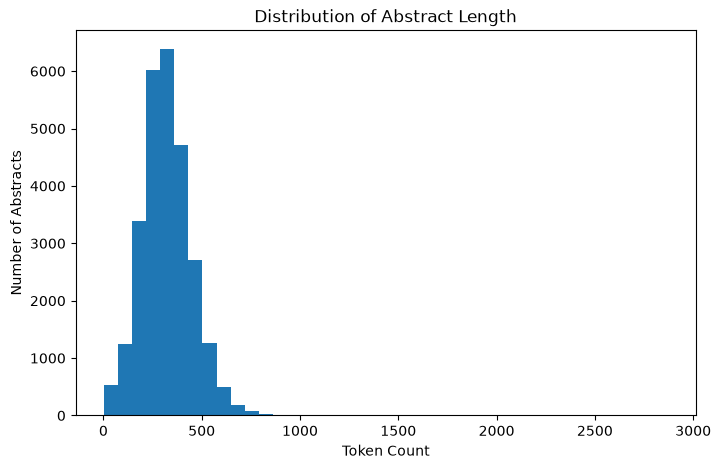

In [18]:
# 绘制token_count的分布直方图
plt.figure(figsize=(8,5))
plt.hist(df_clean["token_count"], bins=40)
plt.xlabel("Token Count")
plt.ylabel("Number of Abstracts")
plt.title("Distribution of Abstract Length")
plt.show()

## 分层抽样

In [19]:
# 根据token_count的分位数划分短、中、长摘要并抽取

Q1 = df_clean["token_count"].quantile(0.33)
Q2 = df_clean["token_count"].quantile(0.66)

short_df = df_clean[df_clean["token_count"] <= Q1]
medium_df = df_clean[
    (df_clean["token_count"] > Q1) &
    (df_clean["token_count"] <= Q2)
]
long_df = df_clean[df_clean["token_count"] > Q2]

short_sample = short_df.sample(10, random_state=42)
medium_sample = medium_df.sample(10, random_state=42)
long_sample = long_df.sample(10, random_state=42)

In [20]:
#导出摘要的metadata和内容到CSV文件

sample_df = pd.concat([
    short_sample,
    medium_sample,
    long_sample
])

sample_df.to_csv(
    "sampled_abstracts.csv",
    index=False
)

## IMRaD结构分析

In [25]:
#定义关键词检测规则
imrad_keywords = {
    "Background": [
        "background",
        "objective",
        "purpose"
    ],
    "Methods": [
        "methods",
        "design",
        "participants",
        "materials and methods"
    ],
    "Results": [
        "results",
        "findings"
    ],
    "Conclusion": [
        "conclusion",
        "conclusions"
    ]
}


def detect_imrad(text):

    text = str(text).lower()

    result = {}

    for sec, kws in imrad_keywords.items():

        result[sec] = any(
            kw in text
            for kw in kws
        )

    return pd.Series(result)

In [26]:
imrad_result = df_clean["abstract"].apply(detect_imrad)

imrad_result.mean() * 100

Background    33.947563
Methods       38.345643
Results       56.288774
Conclusion    33.016987
dtype: float64

## 医学缩写分析

In [27]:
#定义缩写提取规则

pattern = r"\b[A-Z]{2,8}\b"

abbreviations = []

for text in df_clean["abstract"]:

    abbreviations.extend(
        re.findall(pattern, str(text))
    )

In [28]:
abbr_freq = Counter(abbreviations)

abbr_df = pd.DataFrame(
    abbr_freq.most_common(50),
    columns=["Abbreviation", "Frequency"]
)

abbr_df.head(20)

,Abbreviation,Frequency
0,CI,5089
1,DNA,2725
2,COVID,2602
3,IL,2294
4,OR,1926
5,RNA,1907
6,HIV,1875
7,PCR,1394
8,PD,1323
9,II,1266


In [29]:
#定义缩写密度计算函数

def abbreviation_density(text):

    n_abbr = len(
        re.findall(pattern, str(text))
    )

    n_words = len(
        str(text).split()
    )

    return n_abbr / max(n_words, 1)

In [30]:
df_clean["abbr_density"] = (
    df_clean["abstract"]
    .apply(abbreviation_density)
)

df_clean["abbr_density"].describe()

count    27080.000000
mean         0.032023
std          0.041555
min          0.000000
25%          0.004854
50%          0.023529
75%          0.048889
max          4.000000
Name: abbr_density, dtype: float64

## 同义表达分析

In [31]:
#建立一个小型医学术语映射表

synonyms = {
    "heart attack":
        "myocardial infarction",

    "high blood pressure":
        "hypertension",

    "kidney injury":
        "acute kidney injury",

    "lung infection":
        "pneumonia",

    "heart failure":
        "congestive heart failure"
}

In [32]:
for common, clinical in synonyms.items():

    common_count = (
        df_clean["abstract"]
        .str.contains(
            common,
            case=False,
            na=False
        )
        .sum()
    )

    clinical_count = (
        df_clean["abstract"]
        .str.contains(
            clinical,
            case=False,
            na=False
        )
        .sum()
    )

    print(
        f"{common}: {common_count}"
    )

    print(
        f"{clinical}: {clinical_count}"
    )

    print("-"*40)

heart attack: 10
myocardial infarction: 170
----------------------------------------
high blood pressure: 25
hypertension: 377
----------------------------------------
kidney injury: 75
acute kidney injury: 63
----------------------------------------
lung infection: 8
pneumonia: 241
----------------------------------------
heart failure: 184
congestive heart failure: 9
----------------------------------------


## 高频词分析

In [33]:
#统计Top20高频词

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

words = []

for text in df_clean["abstract"]:

    tokens = re.findall(
        r"[A-Za-z]+",
        str(text).lower()
    )

    tokens = [
        t
        for t in tokens
        if t not in stop_words
    ]

    words.extend(tokens)

word_freq = Counter(words)

freq_df = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word","Frequency"]
)

freq_df

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\xukeh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Word,Frequency
0,patients,22123
1,study,19867
2,p,17634
3,using,12200
4,cells,12042
5,results,12032
6,data,10820
7,cell,10652
8,analysis,10528
9,treatment,10044


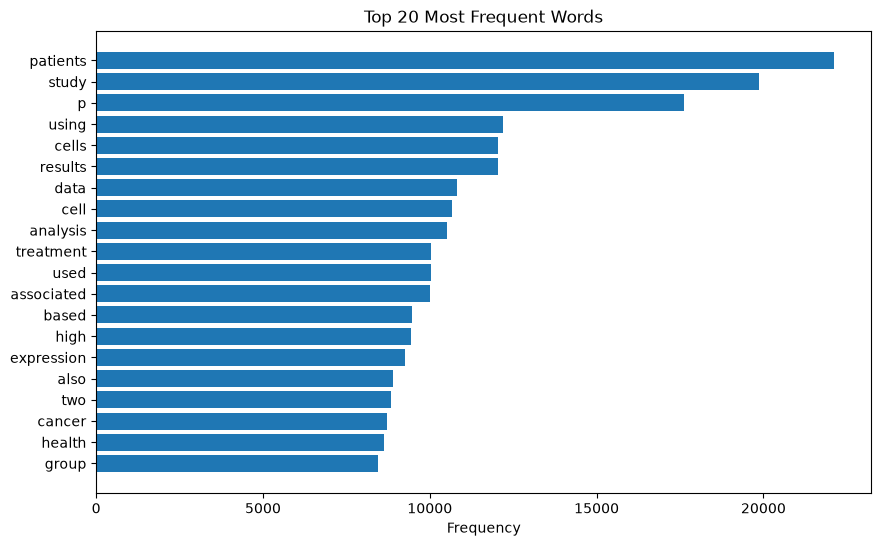

In [34]:
plt.figure(figsize=(10,6))

plt.barh(
    freq_df["Word"][:20][::-1],
    freq_df["Frequency"][:20][::-1]
)

plt.xlabel("Frequency")
plt.title("Top 20 Most Frequent Words")
plt.show()

## 文本特征量化分析

In [35]:
#使用模型的tokenizer来计算每篇abstract的token数量

tokenizer = AutoTokenizer.from_pretrained(
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
    trust_remote_code=True
)

def count_tokens(text):
    return len(
        tokenizer.encode(
            str(text),
            add_special_tokens=False
        )
    )

df_clean["token_count"] = (
    df_clean["abstract"]
    .apply(count_tokens)
)

df_clean["token_count"].describe()

e:\anaconda3\envs\medrag\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\xukeh\.cache\huggingface\hub\models--deepseek-ai--DeepSeek-R1-Distill-Qwen-7B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


count    27080.000000
mean       332.677179
std        139.440744
min          2.000000
25%        242.000000
50%        320.000000
75%        412.000000
max       2993.000000
Name: token_count, dtype: float64

In [36]:
#查看关键分位数

quantiles = (
    df_clean["token_count"]
    .quantile([
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ])
)

print(quantiles)

0.50    320.0
0.75    412.0
0.90    503.0
0.95    565.0
0.99    703.0
Name: token_count, dtype: float64


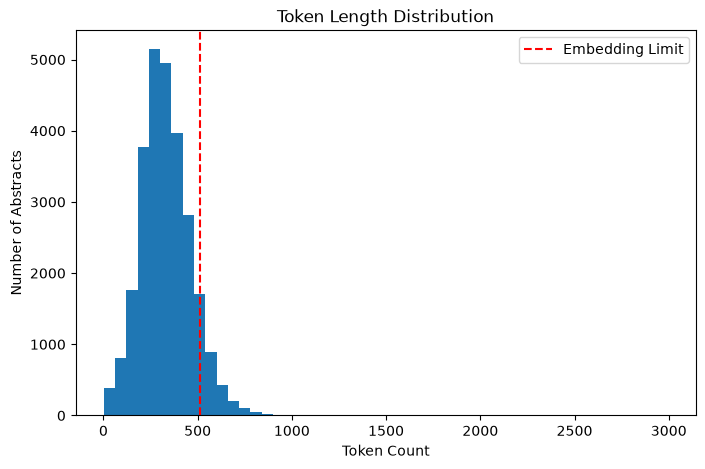

In [37]:
plt.figure(figsize=(8,5))

plt.hist(
    df_clean["token_count"],
    bins=50
)

plt.axvline(
    512,
    color="red",
    linestyle="--",
    label="Embedding Limit"
)

plt.xlabel("Token Count")
plt.ylabel("Number of Abstracts")
plt.title("Token Length Distribution")
plt.legend()

plt.show()

In [38]:
#统计超过512 token的abstract数量和比例

long_docs = df_clean[
    df_clean["token_count"] > 512
]

print(
    f"Long abstracts: {len(long_docs)}"
)

print(
    f"Percentage: {len(long_docs)/len(df_clean)*100:.2f}%"
)

Long abstracts: 2443
Percentage: 9.02%


## 判断是否需要Chunking & Chunking策略

In [39]:
q95 = df_clean["token_count"].quantile(0.95)
q99 = df_clean["token_count"].quantile(0.99)

print(q95)
print(q99)

565.0
703.0


In [40]:
#定义分割策略

MAX_TOKENS = 512
OVERLAP = 80

def count_tokens(text):
    return len(
        tokenizer.encode(
            str(text),
            add_special_tokens=False
        )
    )

def token_chunk_text(text, max_tokens=512, overlap=80):
    tokens = tokenizer.encode(
        str(text),
        add_special_tokens=False
    )

    if len(tokens) <= max_tokens:
        return [str(text)]

    chunks = []
    step = max_tokens - overlap

    for start in range(0, len(tokens), step):
        chunk_tokens = tokens[start:start + max_tokens]
        chunk_text = tokenizer.decode(
            chunk_tokens,
            skip_special_tokens=True
        )
        chunks.append(chunk_text)

        if start + max_tokens >= len(tokens):
            break

    return chunks

In [41]:
#构建chunk-level DataFrame

chunk_records = []

for idx, row in df_clean.iterrows():

    title = str(row.get("title", "")).strip()
    abstract = str(row.get("abstract", "")).strip()

    text = f"Title: {title}\n\nAbstract: {abstract}"

    chunks = token_chunk_text(
        text,
        max_tokens=MAX_TOKENS,
        overlap=OVERLAP
    )

    for chunk_id, chunk_text in enumerate(chunks):
        chunk_records.append({
            "doc_id": idx,
            "chunk_id": chunk_id,
            "n_chunks": len(chunks),
            "title": title,
            "journal": row.get("journal", ""),
            "pub_date": row.get("pub_date", ""),
            "pmid": row.get("pmid", ""),
            "chunk_text": chunk_text,
            "chunk_token_count": count_tokens(chunk_text)
        })

df_chunks = pd.DataFrame(chunk_records)

print(df_chunks.shape)
df_chunks.head()

(30617, 9)


,doc_id,chunk_id,n_chunks,title,journal,pub_date,pmid,chunk_text,chunk_token_count
0,1,0,2,Effects of uncomplicated Descemet membrane end...,Graefe's Archive for Clinical and Experimental...,2021-01-01,33977320,Title: Effects of uncomplicated Descemet membr...,512
1,1,1,2,Effects of uncomplicated Descemet membrane end...,Graefe's Archive for Clinical and Experimental...,2021-01-01,33977320,8 ± 0.92 logMAR) only 1 month after surgery in...,137
2,2,0,1,Therapeutic Potential of Exosomes Derived from...,International Journal of Molecular Sciences,2022-01-01,,Title: Therapeutic Potential of Exosomes Deriv...,400
3,3,0,1,Bacillus anthracis Spore Entry into Epithelial...,PLoS ONE,2010-01-01,20652027,Title: Bacillus anthracis Spore Entry into Epi...,449
4,4,0,1,Iodine and thyroid status during pregnancy and...,Maternal & Child Nutrition,2021-01-01,34350728,Title: Iodine and thyroid status during pregna...,446


In [42]:
#检查分割结果

print(df_chunks["chunk_token_count"].describe())

print(
    "Chunks exceeding 512:",
    (df_chunks["chunk_token_count"] > 512).sum()
)

print(
    "Documents split:",
    df_chunks[df_chunks["n_chunks"] > 1]["doc_id"].nunique()
)

print(
    "Split document rate:",
    df_chunks[df_chunks["n_chunks"] > 1]["doc_id"].nunique() / len(df_clean) * 100
)

count    30617.000000
mean       328.585459
std        124.824544
min         18.000000
25%        238.000000
50%        331.000000
75%        430.000000
max        512.000000
Name: chunk_token_count, dtype: float64
Chunks exceeding 512: 0
Documents split: 3454
Split document rate: 12.754800590841949
